# Numerical PDE Solver Vs Analytical PDE Solver
### Eddie Hutton 


## Introduction

Often, physicists, engineers, and scientists are interested in how something changes; whether that be with respect to time, space, or something else. A differential equation is the mathematical representation of this. It is most natural to at first think about how a variable changes as time goes on. This gives rise to most ordinary differential equations, where it's assumed the sole driver of change is the progression of time. For example consider a population model:

$$
\frac{dP}{dt} = rP
$$

Here time is the only factor the change of population depends on.

However, some physical systems are more complicated. Partial differential equations (PDEs), in fact, started as a branch of physics in the early 18th century. Take for example the distribution of heat. If we consider a point of heat, surrounded by many other points of varying heat, it's obvious this point will evolve in time. Intuitively, it also seems obvious that the surrounding points must also affect how this point evolves, since heat flows from hot to cold. Thus, we formulate a new branch of differential equations where change in states are not solely dependent on one variable, but multiple.

## Background and Motivation
Heat diffusion is a fundamental physical processes in nature, it governs how a hot pan cools on a countertop, how temperature spreads through the Earth's crust, and how drugs diffuse through biological tissue. As with most partial differential equations, solutions can be very difficult to come up with. Most PDEs, in fact, don't have closed form solutions. In practice, a physicist or engineer faced with a heat diffusion problem has two options: solve the equation analytically, obtaining an exact closed-form solution, or solve it numerically, obtaining an approximation by stepping through time on a discretized grid. Both approaches have been studied extensively, but the question of when to use which is rarely addressed directly.

This essay investigates that question for the 2D heat equation with Dirichlet boundary conditions. Specifically: how do an explicit numerical solver (Forward-Time Centered-Space (FTCS) method) and an analytical Fourier series solution compare in accuracy and computational efficiency, and under what conditions does each become the better choice? In large-scale simulations such as climate modeling or semiconductor thermal management, the difference between a method that takes milliseconds and one that takes hours per evaluation is consequential. By building both solvers from the ground up and benchmarking them directly, we aim to give a concrete, quantitative answer to this trade-off for a well-understood physical system. 

Note that Euler's method in literature refers to the method used to solve ODEs, while applying the same logic for PDEs is referred to as FTCS. However, for the remainder of the essay this will be referred to as Euler's method.

Specifically, when we think about heat we consider the progression of the temperature of a point based on time and space. The diffusion equation is:

$$
\frac{\partial T}{\partial t} = D \nabla^2 T
$$

where T=T(x,t), x in meters and t in seconds, is heat (or really concentration of anything, but here we will use heat) at a point and D (m^2/s) is a constant scalar representing rate of diffusion in a system. A quick examination of the equation shows that the change in concentration at a local point (dT/dt) is proportional to the second derivative of the spacial component. If we think back to introductory calculus we remember, the second derivative represents the curvature of the line. So, this equation says the sharper the curve, or the bigger the difference in the local temperature to the point temperature, the more the point will change. 

One last quirk of differential equations is that we must impose some type of boundary condition. Consider two simple cases: 
1. We fix the boundary points, so that they always stay at the same temperature (Dirichlet).
2. We fix the spatial derivative, so the heat flux is consistent (Neumann)

Physically, these may be physical mechanisms or material restrictions such as insulation.

## Numerical Analysis

Let's look at the above equation. Without even trying to solve it, we can see that the heat (i.e. T) will change in proportion to curvature at that point. Using the methods we have discussed in class, particulary Euler's method, we want to change each point at each step (except for the boundary conditions, which have their own rules) in this way. The time step can be discretized as we usually would, by choosing a timestep and discretizing times into points in n
$$\frac{T^{n+1} - T^{n}}{\Delta t}$$

Now, to capture the change based on curvature at a single point, we should want our model to look at the surrounding points and change the single point somehow proportional to these points. A simple method is to take the average and change that point as just the average of the surrounding points as follows:
$$T^{n+1} = T^{n} +\alpha \left( T^{n}_{\text{neighbors}} - T^{n} \right)$$

where alpha is the rate of diffusion in our system. However, this approach is a bit naive. Consider an asymmetric case: the point is already at the average of its neighbors, but the neighbors themselves are distributed unevenly. Pure averaging says "no change," yet the second derivative (the curvature) is nonzero. The heat equation responds to curvature, not simply to deviation from the local mean.

So, in the 2D case the update rule at point (i,j) is approximated as:
$$T^{n+1}_{i,j} = T^n_{i,j} + \alpha \Delta t \left(\frac{T^n_{i+1,j} - 2T^n_{i,j} + T^n_{i-1,j}}{\Delta x^2} + \frac{T^n_{i,j+1} - 2T^n_{i,j} + T^n_{i,j-1}}{\Delta y^2}\right)$$

Or simplified for a uniform grid (where each point is the same distance apart like we will do below):
$$T^{n+1}_{i,j} = T^n_{i,j} + \frac{\alpha \Delta t}{\Delta x^2}\left(T^n_{i+1,j} + T^n_{i-1,j} + T^n_{i,j+1} + T^n_{i,j-1} - 4T^n_{i,j}\right)$$
Often, the diffusivity coefficient, spacial step, and time step are wrapped into a single variable called r:
$$r = \frac{\alpha \Delta t}{\Delta x^2}$$We will use a simple boundary condition for this analysis. The boundary conditions are fixed at zero for all time:

$$T^{n+1}_{0,\,j} = T^{n+1}_{N,\,j} = T^{n+1}_{i,\,0} = T^{n+1}_{i,\,M} = 0$$

Using these equations, we will create a simple euler method process below that will approximate heat diffusion in a 2d system. 

## Numerical Stability

As we have seen, different choices of numerical solvers, initial conditions, timesteps, and parameters can cause numerical instability. For example, Euler's method can introduce energy into systems of motion and cause motion to increase to infinity. We chose different numerical solvers to combat this, particulary the Euler-Cromer method or the Runga-Kutta solver which are common techniques to solve ODEs. When solving PDEs numerically, we can encounter similar problems. 

A numerical PDE solver takes steps in time at every point, so we must be certain no conditions will break our system. There are a number of ways to ensure  numerical stability; a common one is the Von Neumann method (1). It can be shown that our system is only numerically stable when $$r = \frac{\alpha \Delta t}{\Delta x^2} < \frac{1}{4}$$ in the 2d case we examine (2).

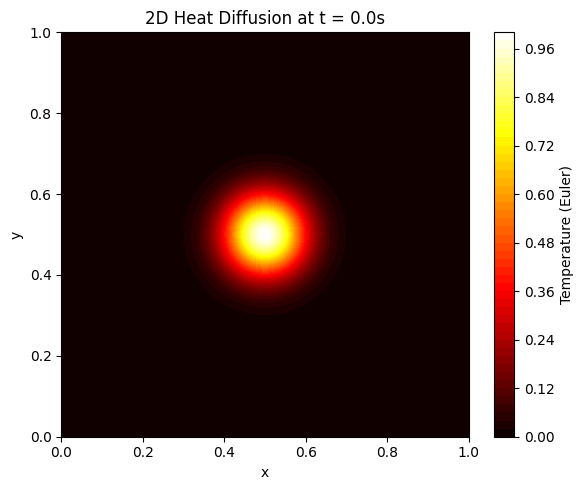

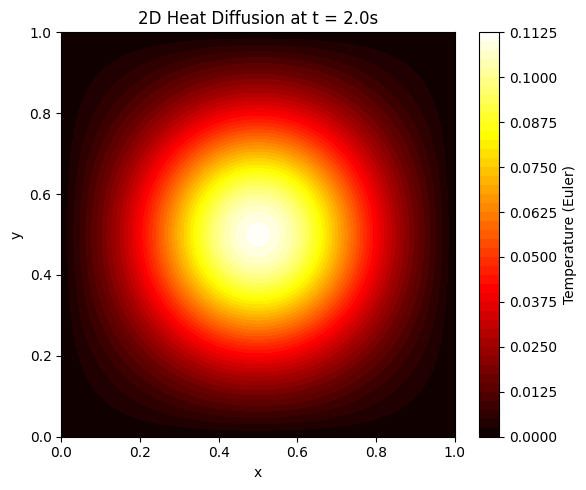

In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0 # grid span
N = 100 # grid points per axis (uniform)
alpha = 0.01 # thermal diffusivity
t_end = 0 # simulation time

dx = L / (N - 1)
# Von Neumann condition for 2D FTCS: r = alpha*dt/dx^2 <= 1/4
dt = 0.9 * dx**2 / (4 * alpha)  # 10% safety margin, since it was a bit unstable at exactly 0.25
nt = int(t_end / dt)

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

# Initial condition
# This can be anything, but a gaussian makes sense for this analysis
T = np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / 0.01)

# ftcs time step
def step_euler(T, alpha, dt, dx):
    '''One explicit Euler step of the 2D heat equation.
    args:
    T (numpy array): Initial temperature grid
    alpha (float): Thermal diffusivity
    dt (float): time step
    dx (float): size of each grid cell (uniform)

    Returns:
    Temperature grid after a time step
    '''
    T_new = T.copy()
    r = alpha * dt / dx**2 # this captures curvature, it controls how much the curvature affects change in points
    # Apply the equation we derived above
    T_new[1:-1, 1:-1] = (T[1:-1, 1:-1]
        + r * (T[2:, 1:-1] + T[:-2, 1:-1]
             + T[1:-1, 2:] + T[1:-1, :-2]
             - 4 * T[1:-1, 1:-1]))
    # Dirichlet bcs
    T_new[0, :] = T_new[-1, :] = T_new[:, 0] = T_new[:, -1] = 0
    return T_new

# run simulation for simulation time
def run_euler(nt, T, alpha, dt, dx):
    T_euler = T.copy() # Start with the initial condition
    for n in range(nt):
        T_euler = step_euler(T_euler, alpha, dt, dx) # Update the grid
    return T_euler
T_euler = run_euler(nt, T, alpha, dt, dx)
# plot final state
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, T_euler, levels=50, cmap='hot')
plt.colorbar(label='Temperature (Euler)')
plt.title(f'2D Heat Diffusion at t = {t_end:.1f}s')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig('heat2d_final.png', dpi=150)
plt.show()

def run_euler(nt, T, alpha, dt, dx):
    T_euler = T.copy() # Start with the initial condition
    for n in range(nt):
        T_euler = step_euler(T_euler, alpha, dt, dx) # Update the grid
    return T_euler
t_end = 2 # simulation time
nt = int(t_end / dt)
T_euler = run_euler(nt, T, alpha, dt, dx)
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, T_euler, levels=50, cmap='hot')
plt.colorbar(label='Temperature (Euler)')
plt.title(f'2D Heat Diffusion at t = {t_end:.1f}s')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig('heat2d_final.png', dpi=150)
plt.show()

This looks pretty reasonable. Our initial condition was a gaussian centered at (0.5, 0.5) which appears to be the point of highest temperature. As time goes on the temperature is diffusing throughout the grid around the center. The temperature also appears to be completely uniform, which is expected since the initial condition was uniform and there's not bias to one direction or another. Also, by our boundary condition (Dirichlet) our boundaries should be 0, which they are here. So far, so good.

# Analytical Solution

In MSU's MTH 442 (Partial Differential Equations) we have extensively studied the solutions and their numerous variations of the diffusion equation. While the exact derivation is outside the scope of this writeup, we can get an idea of what our solution should look like without diving into the exact methods. We need a few things for our solution:
1. We should want the solution to satisfy the boundary condition. For the dirichlet condition we chose above, we need the solution to be 0 at the boundaries.
2. We need our heat to spread out in time
3. As time goes to infinity, since the boundaries are held at zero and there is no heat source, the temperature must decay to zero everywhere in the domain.

The solution of the 2d heat equation for finite boundary conditions is as follows:

$$T(x, y, t) = \sum_{n=1}^{\infty} \sum_{m=1}^{\infty} B_{nm} \sin\left(\frac{n\pi x}{L}\right)\sin\left(\frac{m\pi y}{L}\right) e^{-\alpha \pi^2 \left(\frac{n^2 + m^2}{L^2}\right)t}$$

This is a Fourier series. One can easily verify each of the above conditions. Interestingly, the gaussian distribution shows up! While we won't discuss nor apply it here, the infinite and half-line solutions of the diffusion equation also feature the gaussian (specifically, the gaussian convoluted with the initial distribution).

For this Fourier series, the solution to the coefficient is:
$$B_{nm} = \frac{4}{L^2}\int_0^L \int_0^L f(x,y) \sin\left(\frac{n\pi x}{L}\right)\sin\left(\frac{m\pi y}{L}\right) dx\, dy$$

where f(x,y) is the initial condition. Now, similar to above, we can implement this.

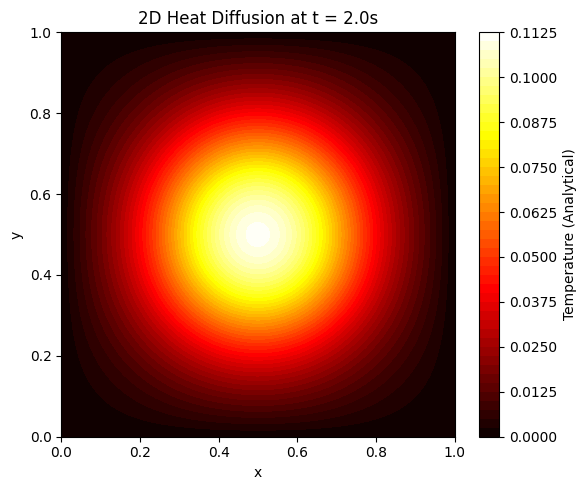

In [5]:
import scipy
import scipy.integrate as integrate
T = np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / 0.01)
n_num = 10 # number of sums


# The logic behind this is that we don't need to recompute every timestep, which slows down the program a lot
# so we will compute once, store the values, then apply them for every timestep
def compute_b(n_num):
    B_list = np.zeros((n_num +1, n_num+1))
    for n in range(1, n_num+1): # start at index 1
        for m in range(1, n_num+1): # using same number of m and n
            B_nm, _ =integrate.dblquad(lambda x, y: np.sin(n*np.pi*x/L)*np.sin(m*np.pi*y/L)*np.exp(-((x - 0.5)**2 + (y - 0.5)**2) / 0.01)
            , 0, L, lambda x: 0, lambda x: L) # hard coded maybe change this later
            B_nm =  4/L**2 * B_nm # unpack then multiply
            B_list[n,m] = B_nm
    return B_list
def step_analytical(T, alpha, dt, dx, N, L, n_num, t, B, X, Y):
    '''
    Evaluates the analytical solution of the 2D heat equation at a specific time using a Fourier series.
    Args:
    T (numpy array): Initial temperature grid 
    alpha (float): Thermal diffusivity constant.
    t (float): elapsed time.
    dx (float): size of each grid cell
    N (int): number of grid cells per axis
    L (float): total length of the spatial domain.
    n_num (int): number of terms to compute in the Fourier series expansion.   

    Returns:
    numpy array: computed temperature grid at time t.
    '''
    T_new = np.zeros_like(T)
    t = t*dt
    for n in range(1, n_num+1):
        for m in range(1, n_num+1):
            T_new += B[n,m] *np.sin(n*np.pi*X/L)*np.sin(m*np.pi*Y/L)*np.exp(-alpha*(np.pi)**2*((n**2+m**2)/L**2)*t)
    return T_new

# unless we want to create some sort of animation we only need the last state, since this is an explicit equation
def run_analytical(n_num, T, alpha, dt, dx, N, L, nt, X, Y):
    B_list = compute_b(n_num)
    T_analytical = step_analytical(T, alpha, dt, dx, N, L, n_num, nt, B_list, X, Y)
    return T_analytical
T_analytical = run_analytical(n_num, T, alpha, dt, dx, N, L, nt, X, Y)

# plot final state
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, T_analytical, levels=50, cmap='hot')
plt.colorbar(label='Temperature (Analytical)')
plt.title(f'2D Heat Diffusion at t = {t_end:.1f}s')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig('heat2d_final.png', dpi=150)
plt.show()

The main insight is that this appears be visually identical to the numerical solutions. This is a good indicator both are working as intended. We should note this is not actually the exact solution since we truncated the fourier series to n=10. This is some what low for this type of analysis, but will make later calculations quicker. So rather, this is an approximation of the exact solution, although in further analysis we will treat it as the exact solution. Even though these appear to be identical, we must perform a quantitative analysis of the computational performance and accuracy.

## Numerical vs Analytical

While these methods both model the same system, there are inevitably variations in performance and results. Generally, we expect numerical solutions to be quick but less accurate than the full analytical solution. Analytical solutions are often considered to be the true or exact solution to a problem. Below, we will compare the two methods. 

As mentioned above, one main disadvantage of a analytical system is the computational cost. Per timestep, analytical solutions are generally much slower than numerical solutions. However, if we only care about the solution at a single time, analytical solutions may be quicker for sufficiently large times, since it must only compute a single time step. We will find the difference between time expenditure per timestep and calculate at what time it becomes more time effective to use an analytical solution. 

One useful error metric will be the average absolute and squared error. For each time step we will look at the average error of a single cell. We should note we expect both models to decay to 0. If we just take the error we will always expect it to go to 0 even if theres a large relative error. So, we will actually be taking the relative error as follows:
$$E = \frac{\sum_{i,j} \left| T^{\text{euler}}_{i,j} - T^{\text{analytical}}_{i,j} \right|}{\sum_{i,j} T^{\text{analytical}}_{i,j}}$$
Further, one property of closed system with dirichlet boundary condition is total heat should decay as time goes on as the walls absorb heat. So, we will track total heat in each system as well.

dx=  0.010101010101010102
dt=  0.0022956841138659324
Average time for one loop of the Euler Simulation: 0.0001 seconds
Average time for one loop of the Analytical Simulation: 0.0481 seconds
Eulers method is 322.59x times faster than the analytical method
Analytical becomes faster after t = 0.7406s (322 steps)


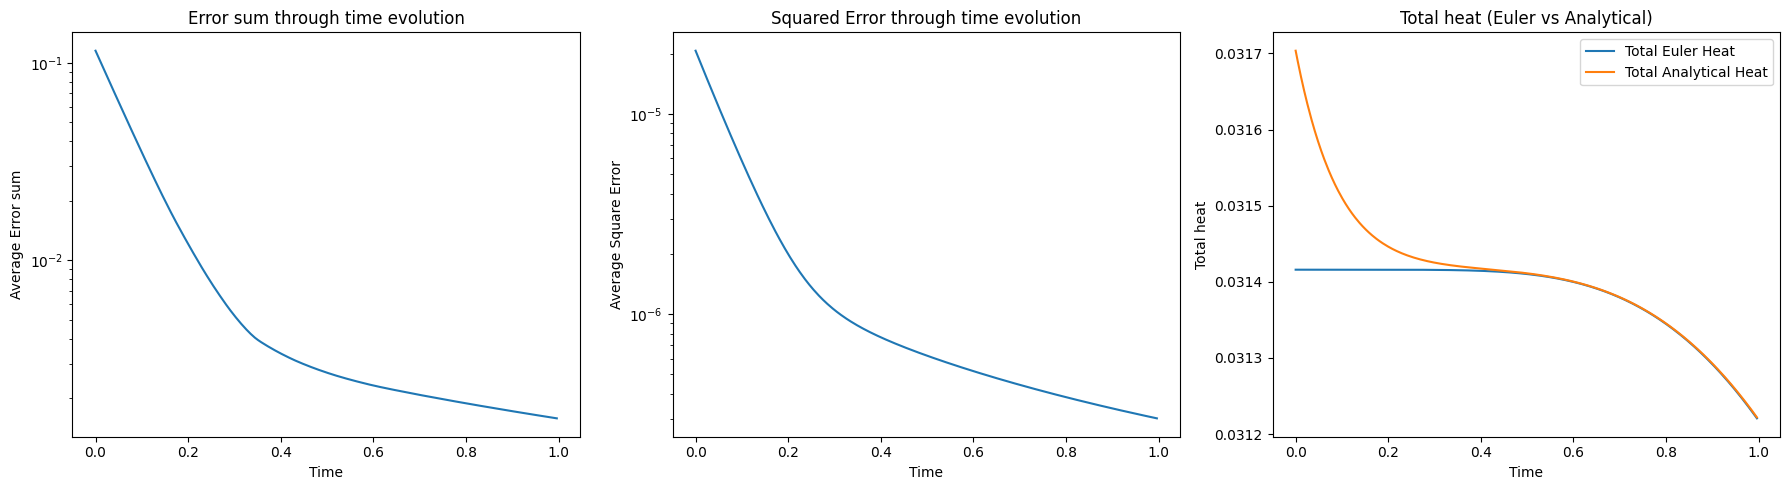

In [13]:
import time

t_end = 1 # simulation time, shorter for this since analytical has to run all
nt = int(t_end / dt)
def compare(X, Y, n_num, t_end=1, alpha=0.01, dx_factor=1, n_snapshots=50):
    """
    Runs and compares an explicit Euler and an analytical solution for a 2D heat diffusion simulation.

    Args:
    X (ndarray): 2D meshgrid of x-coordinates.
    Y (ndarray): 2D meshgrid of y-coordinates.
    n_num (int): Number of Fourier modes for the analytical solution.
    t_end (float): Total simulation time (default: 1).
    alpha (float): Thermal diffusivity (default: 0.01).
    dx_factor (float): Spatial resolution scaling factor (default: 1).
    n_snapshots (int): Number of time points to compare (default: 50).
    
    Returns:
    None. Prints performance timings and plots error/heat conservation over time.
    """
    dx = (L / (N - 1)) * dx_factor
    N_new = int((N - 1) / dx_factor) + 1
    print('dx= ', dx)
    dt = 0.9 * dx**2 / (4 * alpha)
    print('dt= ', dt)
    nt = int(t_end / dt)

    x = np.linspace(0, L, N_new)
    y = np.linspace(0, L, N_new)
    X_new, Y_new = np.meshgrid(x, y)

    T_init = np.exp(-((X_new - 0.5)**2 + (Y_new - 0.5)**2) / 0.01)
    T_euler = T_init.copy()

    total_heat_e = []
    total_heat_a = []
    relative_errors = []
    relative_errors_2 = []
    snapshot_times = []
    time_analytical = []
    time_euler = []

    B_list = compute_b(n_num)

    # Speed up analytical solution by only running steps at n time stamps
    snapshot_steps = set(np.linspace(0, nt - 1, n_snapshots, dtype=int))

    for n in range(nt):
        t_start_e = time.time()
        T_euler = step_euler(T_euler, alpha, dt, dx)
        t_end_e = time.time()
        time_euler.append(t_end_e - t_start_e)

        if n in snapshot_steps:
            t_start_a = time.time()
            T_analytical = step_analytical(T_init, alpha, dt, dx, N_new, L, n_num, n, B_list, X_new, Y_new)
            t_end_a = time.time()
            time_analytical.append(t_end_a - t_start_a)

            heat_e = T_euler.sum() * dx ** 2
            heat_a = T_analytical.sum() * dx ** 2
            relative_error = (abs(T_euler - T_analytical)).sum() / heat_a * (dx ** 2)
            relative_error_2 = np.sqrt(((T_euler - T_analytical)**2).mean()) / heat_a * (dx ** 2)

            total_heat_e.append(heat_e)
            total_heat_a.append(heat_a)
            relative_errors.append(relative_error)
            relative_errors_2.append(relative_error_2)
            snapshot_times.append(n * dt)
        #if n % 200 == 0:
            #print('n', n)
            #print('nt', nt)

    print(f'Average time for one loop of the Euler Simulation: {np.mean(time_euler):.4f} seconds')
    print(f'Average time for one loop of the Analytical Simulation: {np.mean(time_analytical):.4f} seconds')
    ratio = np.mean(time_analytical) / np.mean(time_euler)
    print(f'Eulers method is {ratio:.2f}x times faster than the analytical method')
    nt_crossover = np.mean(time_analytical) / np.mean(time_euler)
    t_crossover = nt_crossover * dt
    print(f'Analytical becomes faster after t = {t_crossover:.4f}s ({int(nt_crossover)} steps)')

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # average errors (sum)
    axs[0].plot(snapshot_times, np.array(relative_errors))
    axs[0].set_title('Error sum through time evolution')
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Average Error sum')
    axs[0].set_yscale('log')

    # average errors (squared error)
    axs[1].plot(snapshot_times, np.array(relative_errors_2))
    axs[1].set_title('Squared Error through time evolution')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Average Square Error')
    axs[1].set_yscale('log')

    # Total heat
    axs[2].plot(snapshot_times, total_heat_e, label='Total Euler Heat')
    axs[2].plot(snapshot_times, total_heat_a, label='Total Analytical Heat')
    axs[2].set_title('Total heat (Euler vs Analytical)')
    axs[2].set_xlabel('Time')
    axs[2].set_ylabel('Total heat')
    axs[2].legend()

    plt.tight_layout()
    plt.show()
compare(X, Y, n_num, t_end=1, alpha=0.01, n_snapshots=300)

## Grid resolution

Another interesting property will be comparing how grid resolution affects error and time. Note, as we decrease dx, dt will also decrease due to our stability condition. One thing we may expect as we decrease dx is our error will decrease. Our model will more accurately capture the shape of the initial distribution and we get closer to a continuous solution which is what our analytical solution models. However, since dt and dx both decrease, the model will take significantly longer. Halving dx should cause a 4x slow down. 

Half of initial dx

dx=  0.005050505050505051
dt=  0.0005739210284664831
Average time for one loop of the Euler Simulation: 0.0004 seconds
Average time for one loop of the Analytical Simulation: 0.1784 seconds
Eulers method is 438.19x times faster than the analytical method
Analytical becomes faster after t = 0.2515s (438 steps)


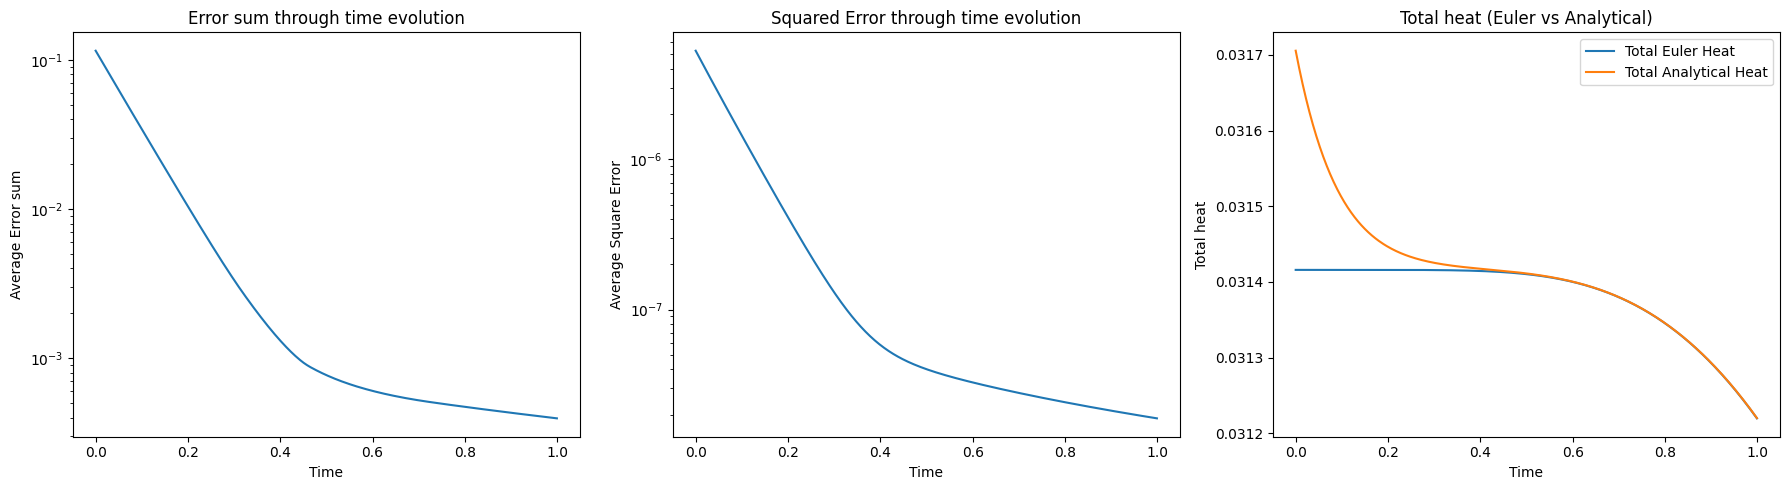

Quarter of the initial dx

dx=  0.0025252525252525255
dt=  0.00014348025711662078
Average time for one loop of the Euler Simulation: 0.0073 seconds
Average time for one loop of the Analytical Simulation: 1.3920 seconds
Eulers method is 191.72x times faster than the analytical method
Analytical becomes faster after t = 0.0275s (191 steps)


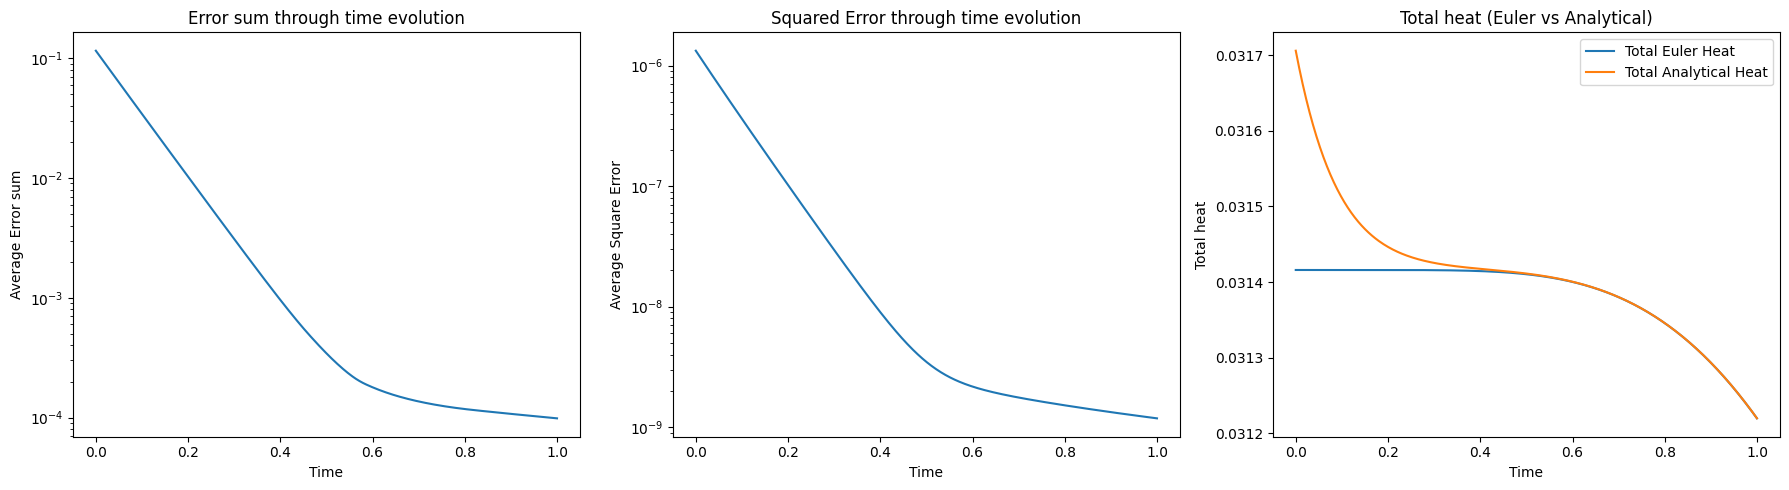

In [15]:
print('Half of initial dx\n')
compare(X, Y, n_num, t_end=1, alpha=0.01, dx_factor=0.5, n_snapshots=400) # This is half of the above dx
print('Quarter of the initial dx\n')
compare(X, Y, n_num, t_end=1, alpha=0.01, dx_factor=0.25, n_snapshots=400) # This a quarter of the above dx
#print('Tenth of the initial dx\n')
#compare(X, Y, n_num, t_end=1, alpha=0.01, dx_factor=0.1) # This a tenth of the above dx

## Analysis and Discussion

Let's revisit our initial question. First, time efficiency. Per time step, Euler's method is a staggering 200-400x quicker than the analytical method. Euler's method is essentially all arithemitic, which computers do quite quickly. The analytical method requires infinite series sums for every single point, which slows down computation significantly. However, analytical solutions have a distinct advantage, which is that they can jump straight to a timestep without needing to compute every single time before. This "crossover time" is not a universal constant, it depends on the grid resolution. As N increases, the stability condition forces a smaller dt, meaning Euler must take more steps to reach any given physical time, while the analytical method's cost remains fixed per evaluation. Thus for finer grids, the analytical method becomes advantageous at earlier physical times. The crossover time scales as dt itself, so high-resolution simulations favor the analytical approach even sooner. So, we conclude that if we need to calculate a large time it's actually quicker to use the analytical method.

Next, we evaluate the error plots. Both error plots tell the same story: as time goes on error decreases. After just a few tenths of a second both errors drop significantly. We didn't define any quantitative accuracy threshold; but qualitatively we can say as time goes on the relative error decreases. One interpetation is that the system is correcting itself, since both solutions are being "pulled" towards 0. The conservation plot is a little more interesting. Total heat (K/m^2) in the analytical system starts higher than in the numerical system before quickly converging. This can be attributed to the truncation in the infinite series. The analytical state is an imperfect approximation of the gaussian curve, so heat maybe under or over approximated.

Finally, as we make dx finer and finer, error goes down significantly(note the log plots). Total heat remains completely unchanged. Additionally, as dx gets finer, Eulers method becomes even more efficient per step and the cross over time goes down. Both methods take 2-3x longer per timestep. This shows we increase the resolution of the grid, analytical solutions are slower per timestep but actually becomes more efficient to use for large times.

## Sources

1. MIT, https://math.mit.edu/classes/18.300/Notes/Notes_vNSA.pdf
2. Recktenwald, https://web.cecs.pdx.edu/~gerry/class/ME448/notes/1Dmodels/pdf/FTCS_slides.pdf